In [11]:
import numpy as np
import math
from scipy.constants import m_e, c, e, hbar, physical_constants, epsilon_0
from scipy.special import gamma
import tqdm
import numba
import matplotlib.pyplot as plt
import pandas as pd

# Temperature from ionization

In [3]:
Uion = 13.6*e  # ionization energy in Joules, for Hydrogen

# Calculate the ADK prefactors (See Chen, JCP 236 (2013), equation (2))
# - Scalars
alpha = physical_constants['fine-structure constant'][0]
r_e = physical_constants['classical electron radius'][0]
wa = alpha**3 * c / r_e
Ea = m_e*c**2/e * alpha**4/r_e
# - Arrays (one element per ionization level)
UH = 13.6*e
Z = 1
n_eff = Z * np.sqrt( UH/Uion )
l_eff = n_eff - 1
C2 = 2**(2*n_eff) / (n_eff * gamma(n_eff+l_eff+1) * gamma(n_eff-l_eff))
# For now, we assume l=0, m=0
adk_power = - (2*n_eff - 1)
adk_prefactor = wa * C2 * ( Uion/(2*UH) ) \
    * ( 2*(Uion/UH)**(3./2)*Ea )**(2*n_eff - 1)
adk_exp_prefactor = -2./3 * ( Uion/UH )**(3./2) * Ea

In [9]:
@numba.njit
def get_ib_heating_rate( a, n0, kin_energy, ioniz_frac, lambd ):

    # Compute thermal velocity
    kin_energy_per_electron = kin_energy/ioniz_frac
    vth_over_c = math.sqrt( kin_energy_per_electron/(3/2*m_e*c**2) )
    
    # Compute Coulomb log
    vbar_over_c = math.sqrt( vth_over_c**2 + a**2/6 ) # Eq. 4.56 in Pierre Michel's book
    bmin = 0.5*hbar/(m_e*c*vbar_over_c) # Eq. 4.58 in Pierre Michel's book
    bmax = vbar_over_c * lambd/(2*math.pi) # Eq. 4.59 in Pierre Michel's book
    bperp = r_e / vbar_over_c**2 # Eq. 4.60 in Pierre Michel's book
    C_log = 0.5*np.log( (1 + (bmax/bperp)**2 )/(1 + (bmin/bperp)**2) )

    # Compute heating rate
    n_i = n0*ioniz_frac
    if ( vth_over_c > a ):
        nu_ei = 4*(2*np.pi)**.5/3 * (n_i * r_e**2 * c) * C_log/vth_over_c**3 # Eq. 4.21 in Pierre Michel's book
    else:
        nu_ei = 16 * (n_i * r_e**2 * c) * C_log / a**3 * np.log( 2**.5 * a/vth_over_c ) # Eq. 4.36 in Pierre Michel's book

    heating_per_electron =  0.5 * m_e*c**2 * a**2 * nu_ei
    return heating_per_electron


@numba.njit
def get_fraction_and_temperature( a0, tau, lambd, ell, npts_per_wavelength=80, 
        compute_inverse_bremsstrahlung=False, n0=0., npts_per_tau_ib=80 ):
    """
    a0: Peak laser amplitude
    tau: laser duration
    lambd: laser wavelength
    ell: polarization vector
    n0: electron density if the plasma was fully ionized
    """
    # Precompute a few things
    omega = 2*np.pi*c/lambd
    E0 = m_e*omega*c/e
    inv_tau2 = 1./tau**2
    # Check the ellipticity
    assert len(ell) == 2
    assert abs(ell[0]**2 + ell[1]**2 - 1) < 1.e-10 # Check that the ellipticity is normalized

    t = -3*tau # Start at 3 sigma
    ioniz_frac = 0
    kin_energy = 0

    if compute_inverse_bremsstrahlung:
        assert n0 > 0
        assert (ell[1] < 1.e-10) or (ell[0] < 1.e-10) # Only works for linear polarization

    # Loop for ADK: small timestep
    dt = lambd/c/npts_per_wavelength
    while ((ioniz_frac < 0.999) and (t < 3*tau)):

        # Get the electric field and vector potential
        a_env = a0 * math.exp(-inv_tau2*t**2)
        a = a_env * math.sqrt( ell[0]**2*np.cos(omega*t)**2 + ell[1]**2*np.sin(omega*t)**2 )
        E = E0 * a_env * math.sqrt( ell[0]**2*np.sin(omega*t)**2 + ell[1]**2*np.cos(omega*t)**2 )                           

        # Get the ionization rate
        w = 0
        if E > 0:
            w = adk_prefactor * E**adk_power * math.exp( adk_exp_prefactor/E )
        dp = 1 - math.exp( -w*dt )

        # increment the ionization fraction
        kin_energy += (1 - ioniz_frac)*dp * m_e*c**2 * (math.sqrt( 1 + a**2 ) - 1)
        ioniz_frac += (1 - ioniz_frac)*dp

        if compute_inverse_bremsstrahlung and (ioniz_frac>0):
            kin_energy += dt * ioniz_frac * get_ib_heating_rate( a_env, n0, kin_energy, ioniz_frac, lambd )

        t += dt

    # Once the plasma is fully ionized we can take much larger timesteps to compute IB
    if compute_inverse_bremsstrahlung:
        dt = tau/npts_per_tau_ib        
        while (t < 3*tau):
            a_env = a0 * math.exp(-inv_tau2*t**2)
            kin_energy += dt * ioniz_frac * get_ib_heating_rate( a_env, n0, kin_energy, ioniz_frac, lambd )
            t += dt

    T = 0.
    if ioniz_frac > 0:
        T = kin_energy/(3/2*ioniz_frac*e)

    return ioniz_frac, T, t

def save_radial_csv(r_coords, ioniz_frac, T_eV, output_file):
    """
    Save 1D radial data to CSV file
    
    Parameters:
    -----------
    r_coords : array-like Radial coordinates (m)
    ioniz_frac : array-like Ionization fractions
    output_file : str Output filename
    """
    data_dict = {
        'Radius (cm)': r_coords * 100,  
        'Ionization Fraction': ioniz_frac,
        'Electron Temperature (K)': T_eV * 11604 
    }
    
    df = pd.DataFrame(data_dict)
    df.to_csv(output_file, index=False, float_format='%.4e')
    print(f"Radial profile data saved to {output_file}")


def load_intensity_profile(filename):
    """
    Load intensity profile from txt or csv file
    
    Parameters:
    -----------
    filename : str, Path to file containing intensity data
        
    Returns:
    --------
    intensity_array : 1D or 2D array intensity values (W/m^2)
    """
    if filename.endswith('.csv'):
        intensity_array = np.loadtxt(filename, delimiter=',')
    else:
        intensity_array = np.loadtxt(filename)
    
    return intensity_array

def process_intensity_array(intensity_array, lambd, tau, ell, compute_inverse_bremsstrahlung=False, n0=0., 
                          output_file=None, r_coords=None):
    """
    Process a 1D intensity array to calculate ionization fraction and temperature
    
    Parameters:
    -----------
    intensity_array : 1D  array
        Laser intensity values (W/m^2) radial intensity profile I(r)
    lambd : float
        Laser wavelength (m)
    tau : float
        Laser pulse duration (s)
    ell : array-like
        Polarization vector [2-element array]
    compute_inverse_bremsstrahlung : bool, optional
        Whether to include inverse bremsstrahlung heating (default: False)
    n0 : float, optional
        Electron density if plasma was fully ionized (m^-3) (default: 0)
    output_file : str, optional
        Filename to save CSV output with radius, ionization fraction, and temperature
    r_coords : array-like, optional
        Radial coordinates (m). Required for 1D data if output_file is specified.
        For 2D data, used to determine radial sampling for CSV output.
    
    Returns:
    --------
    ioniz_frac_array : 1D or 2D array
        Ionization fractions (same shape as input)
    T_array : 1D or 2D array
        Electron temperatures in eV (same shape as input)
    """
    # Convert intensity to normalized vector potential a0
    a0_array = e * lambd / (np.pi * m_e * c) * np.sqrt(intensity_array / (2 * epsilon_0 * c**3))
    
    # Initialize output arrays
    ioniz_frac_array = np.zeros_like(a0_array)
    T_array = np.zeros_like(a0_array)
    
    for i in tqdm.tqdm(range(len(a0_array)), desc="Processing 1D intensity profile"):
        ioniz_frac, T, _ = get_fraction_and_temperature(
            a0_array[i], tau, lambd, ell, 
            compute_inverse_bremsstrahlung=compute_inverse_bremsstrahlung, 
            n0=n0
        )
        ioniz_frac_array[i] = ioniz_frac
        T_array[i] = T
        
    # Save CSV output for 1D data
    if output_file and r_coords is not None:
        save_radial_csv(r_coords, ioniz_frac_array, T_array, output_file)
    
    return ioniz_frac_array, T_array

In [5]:
a0 = 0.05
tau = 30e-15
lambd = 0.8e-6
ell = np.array([0,1]) 

get_fraction_and_temperature( a0, tau, lambd, ell )

(0.999015549502642, 2.810820266987407, -3.089244233088865e-14)

Text(0, 0.5, 'Temperature (eV)')

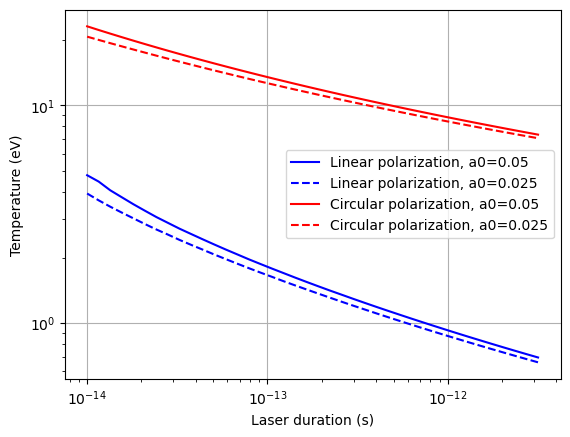

In [6]:
tau_arr = 10**np.linspace(-14, -11.5, 40)

a0 = 0.05
ell = np.array([0,1]) 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'b-', label='Linear polarization, a0=0.05' )

a0 = 0.025
ell = np.array([0,1]) 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'b--', label='Linear polarization, a0=0.025' )

a0 = 0.05
ell = np.array([1,1])/2**.5 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'r-', label='Circular polarization, a0=0.05' )

a0 = 0.025
ell = np.array([1,1])/2**.5 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'r--', label='Circular polarization, a0=0.025' )

plt.grid()
plt.legend(loc=0)

plt.xlabel('Laser duration (s)')
plt.ylabel('Temperature (eV)')

# Ionization volume for a focusing pulse

In [7]:
a0 = 0.05
w0 = 5.e-6
lambd = 0.8e-6
tau = 1.5e-12
ell = np.array([0,1]) 

zr = np.pi*w0**2/lambd

In [ ]:
zmax = 400e-6
rmax = 50e-6
r, z = np.meshgrid( np.linspace(-rmax, rmax, 100), np.linspace(-zmax, zmax, 100), indexing='ij' )
a = a0/np.sqrt(1 + z**2/zr**2)*np.exp( -r**2/w0**2/(1+z**2/zr**2) )

n = np.zeros_like( a )
T = np.zeros_like( a )
for i in tqdm.tqdm( range(n.shape[0]) ):
    for j in range(n.shape[1]):
        ion, T0, _ = get_fraction_and_temperature( a[i,j], tau, lambd, ell, compute_inverse_bremsstrahlung=True, n0=2e24 )
        n[i,j] = ion
        T[i,j] = T0

In [ ]:
plt.figure(figsize=(5,8))

extent = 1.e6*np.array([-zmax, zmax, -rmax, rmax])

plt.subplot(311)
plt.imshow(a, extent=extent, aspect='auto', cmap='gist_heat_r')
cb = plt.colorbar()
cb.set_label('a (laser)')
plt.ylabel('r (microns)')

plt.subplot(312)
plt.imshow(2e18*n, extent=extent, aspect='auto', cmap='gist_heat_r', vmax=2.5e18)
cb = plt.colorbar()
cb.set_label('$n_e\;(cm^{-2})$')
plt.ylabel('r (microns)')

plt.subplot(313)
plt.imshow(T, extent=extent, aspect='auto', cmap='gist_heat_r', vmax=20)
cb = plt.colorbar()
cb.set_label('T (eV)')
plt.ylabel('r (microns)')

Example 1: 1D radial profile
Loaded 1D profile shape: (100,)
Data match: True


Processing 1D intensity profile: 100%|██████████| 100/100 [00:00<00:00, 307.71it/s]


Radial profile data saved to plasma_from_file.csv


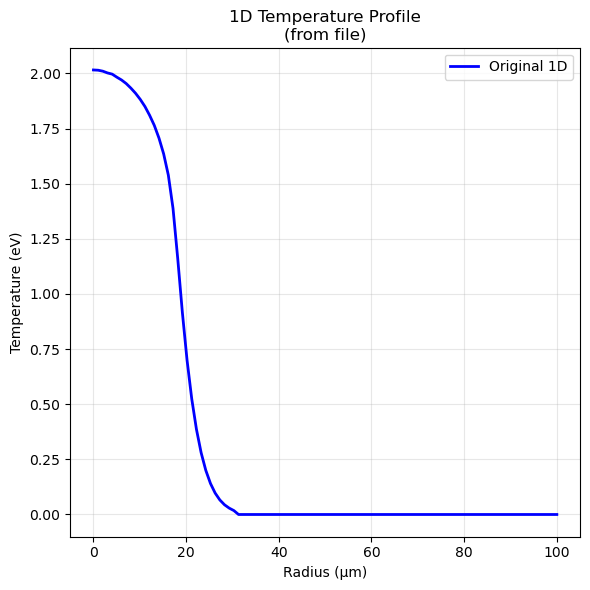

In [13]:
#example of writing and reading gaussian laser intensity from file and plotting 1d temperature

lambd = 0.8e-6
tau = 50e-15
ell = np.array([1, 0])  # linear polarization

# Example: 1D radial intensity profile (cylindrical symmetry)
print("Example 1: 1D radial profile")
r_1d = np.linspace(0, 100e-6, 100)  # radial coordinate from 0 to 100 microns
w0_1d = 20e-6  # beam waist
I0_1d = 1e19  # peak intensity in W/m^2
intensity_1d = I0_1d * np.exp(-2*r_1d**2/w0_1d**2)

sample_1d_data = intensity_1d  
np.savetxt('sample_radial_intensity.txt', sample_1d_data)
np.savetxt('sample_radial_intensity.csv', sample_1d_data, delimiter=',')

# Load from files
intensity_from_txt = load_intensity_profile('sample_radial_intensity.txt')
intensity_from_csv = load_intensity_profile('sample_radial_intensity.csv')

print(f"Loaded 1D profile shape: {intensity_from_txt.shape}")
print(f"Data match: {np.allclose(intensity_from_txt, intensity_from_csv)}")

# Process the loaded 1D data
ioniz_frac_file, T_eV_file = process_intensity_array(intensity_from_txt, lambd, tau, ell,
                                                    output_file='plasma_from_file.csv',
                                                    r_coords=r_1d)

plt.figure(figsize=(6, 6))

plt.plot(r_1d*1e6, T_eV_file, 'b-', linewidth=2, label='Original 1D')
plt.xlabel('Radius (μm)')
plt.ylabel('Temperature (eV)')
plt.title('1D Temperature Profile\n(from file)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Clean up sample files
import os
os.remove('sample_radial_intensity.txt')
os.remove('sample_radial_intensity.csv')

# Inverse Bremstrahlung details

In [ ]:
n0 = 2e24
a0 = 0.05
lambd = 0.8e-6
tau = 1.5e-12
ell = np.array([0,1]) 

ioniz_frac, T_eV, t0 = get_fraction_and_temperature(a0, tau, lambd, ell)

t_arr = np.linspace(-5e-12, 5e-12, 200)
a_arr = a0*np.exp(-t_arr**2/tau**2)

# Compute Coulomb log
vth_over_c = math.sqrt( T_eV*e/(m_e*c**2) ) # no additional factor of 1/3 here
vbar_over_c = np.sqrt( vth_over_c**2 + a_arr**2/6 ) # Eq. 4.56 in Pierre Michel's book
bmin = 0.5*hbar/(m_e*c*vbar_over_c) # Eq. 4.58 in Pierre Michel's book
bmax = vbar_over_c * lambd/(2*np.pi) # Eq. 4.59 in Pierre Michel's book
bperp = r_e / vbar_over_c**2 # Eq. 4.60 in Pierre Michel's book
C_log = 0.5*np.log( (1 + (bmax/bperp)**2 )/(1 + (bmin/bperp)**2) )

n_i = n0*ioniz_frac
nu_ei_lf = 4*(2*np.pi)**.5/3 * (n_i * r_e**2 * c) * C_log/vth_over_c**3 # Eq. 4.21 in Pierre Michel's book
nu_ei_hf = 16 * (n_i * r_e**2 * c) * C_log / a_arr**3 * np.log( 2**.5 * a_arr/vth_over_c )
nu_ei_hf = nu_ei_hf * (nu_ei_hf > 0)

heating_per_electron_lf = 0.5 * m_e*c**2 * a_arr**2 * nu_ei_lf
heating_per_electron_hf = 0.5 * m_e*c**2 * a_arr**2 * nu_ei_hf
heating_per_electron = np.where( vth_over_c < a_arr, heating_per_electron_hf, heating_per_electron_lf )

plt.figure(figsize=(5,10))

plt.subplot(411)
plt.semilogy( t_arr, a_arr )
plt.axvline( x=t0, color='r' )
plt.ylabel('Laser amplitude (a0)')

plt.subplot(412)
plt.plot( t_arr, C_log )
plt.ylabel('Coulomb log')

plt.subplot(413)
plt.semilogy( t_arr, nu_ei_lf, label='Low-field limit' )
plt.semilogy( t_arr, nu_ei_hf, label='High-field limit' )
plt.legend(loc=0)
plt.ylabel('Collision frequency ($s^{-1}$)')

plt.subplot(414)
#plt.plot( t_arr, heating_per_electron_lf*1e-12/e, label='Low-field limit' )
#plt.plot( t_arr, heating_per_electron_hf*1e-12/e, label='High-field limit' )
plt.plot( t_arr, heating_per_electron*1e-12/e )
plt.axvline( x=t0, color='r' )
plt.ylim(0, 15)
plt.ylabel('Heating rate per\n electron ($eV.ps^{-1}$)')

In [ ]:
dt = t_arr[1] - t_arr[0]
energy_per_electron = (heating_per_electron * (t_arr>t0)).sum() * dt
T_ib_eV = energy_per_electron/(3/2*e)

In [ ]:
T_ib_eV

In [ ]:
_, T_ib_eV2, _ = get_fraction_and_temperature(a0, tau, lambd, ell, compute_inverse_bremsstrahlung=True, n0=n0)
print( T_ib_eV2 )